# Model Construction

In [43]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pathlib import Path

In [30]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [31]:
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VAL_CSV = DATA_DIR / "val_split.csv"
TEST_CSV = DATA_DIR / "test_split.csv"

CLASSES = ["malignant", "benign", "normal"]
label_map = {c: i for i, c in enumerate(CLASSES)}

## Retrive images 

Using device: mps
Total: 780 | Train: 563 | Val: 100 | Test: 117

Class distribution:
Train: [152 315  96]
Val: [27 56 17]
Test: [31 66 20]


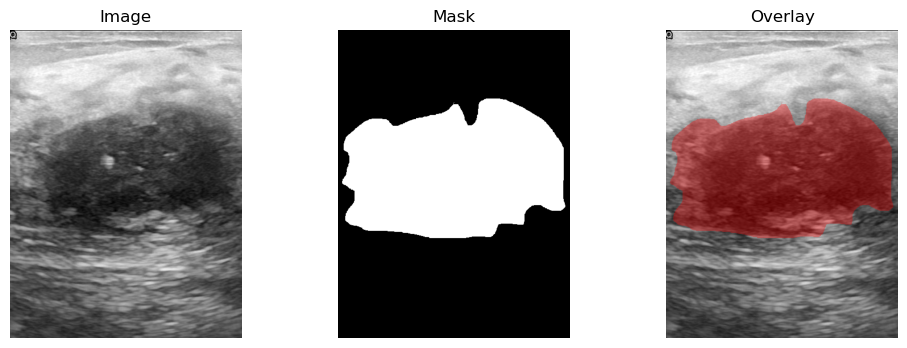

Saved train_split.csv, val_split.csv, and test_split.csv to ../data/


In [32]:
# Pull in all preprocessing and dataset pipeline helpers from the other notebook.
# This keeps this notebook focused purely on model architecture and evaluation.
%run msb_data_preprocessing.ipynb

In [33]:
BATCH_SIZE = 32
USE_MASKS = True

transform, train_transform = get_default_transforms()

datasets, loaders = prepare_data_pipeline(
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    label_map,
    batch_size=BATCH_SIZE,
    use_masks=USE_MASKS,
    transform=transform,
    train_transform=train_transform,
)

train_dataset = datasets['train']
val_dataset = datasets['val']
test_dataset = datasets['test']

train_loader = loaders['train']
val_loader = loaders['val']
test_loader = loaders['test']


## CNN model for ML

In [44]:
class BreastUS_ResNet(nn.Module):
    """
    Transfer learning with ResNet18 for breast ultrasound classification.
    - Pretrained ResNet18 backbone (ImageNet weights)
    - Modified first conv to accept 2 channels (grayscale + mask)
    - Custom classifier head with dropout
    """
    def __init__(self, num_classes=3, input_channels=2, pretrained=True):
        super(BreastUS_ResNet, self).__init__()
        
        # Load pretrained ResNet18
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        # Modify first conv layer: 3 channels -> 2 channels
        # Average the pretrained weights across RGB channels
        old_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        
        # Initialize with averaged pretrained weights
        if pretrained:
            with torch.no_grad():
                # Average RGB weights -> single channel, then tile for input_channels
                avg_weights = old_conv.weight.mean(dim=1, keepdim=True)
                self.backbone.conv1.weight = nn.Parameter(
                    avg_weights.repeat(1, input_channels, 1, 1)
                )
        
        # Replace classifier head
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

In [35]:
# Simple class weighting based on inverse frequency
# CLASSES = ["malignant", "benign", "normal"]
# Benign is the majority class, so we don't over-weight minority classes
train_df = pd.read_csv(TRAIN_CSV)
class_counts = train_df['label'].value_counts()
print("Class distribution in training set:")
print(class_counts)

# Simple weights: inverse of class frequency, normalized
# This gives equal importance to each class without over-correction
class_to_idx = {name: idx for idx, name in enumerate(CLASSES)}
class_weights = np.ones(len(CLASSES))

for class_name, count in class_counts.items():
    idx = class_to_idx[class_name]
    class_weights[idx] = len(train_df) / (len(CLASSES) * count)

print(f"\nClass weights: {dict(zip(CLASSES, class_weights))}")

# Use standard CrossEntropyLoss (more stable than Focal Loss)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Class distribution in training set:
label
benign       315
malignant    152
normal        96
Name: count, dtype: int64

Class weights: {'malignant': np.float64(1.2346491228070176), 'benign': np.float64(0.5957671957671957), 'normal': np.float64(1.9548611111111112)}


In [36]:
def compute_correct_labels(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = torch.sum(preds == labels).item()
    total = labels.size(0)
    return correct, total


In [37]:
def training_loop(model, optimizer, scheduler, num_epochs, train_loader, val_loader, test_loader, class_names):
    train_losses, val_losses, test_losses = [], [], []
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_class_correct = {i: 0 for i in range(len(class_names))}
        val_class_total = {i: 0 for i in range(len(class_names))}
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
                for i in range(len(y)):
                    label = y[i].item()
                    pred = preds[i].item()
                    val_class_total[label] += 1
                    if label == pred:
                        val_class_correct[label] += 1

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)
        
        val_class_accs = []
        for i in range(len(class_names)):
            if val_class_total.get(i, 0) > 0:
                val_class_accs.append(val_class_correct[i] / val_class_total[i])
        
        if len(val_class_accs) == len(class_names):
            min_class_acc = min(val_class_accs)
            balanced_score = val_acc * (0.7 + 0.3 * min_class_acc)
        else:
            balanced_score = val_acc
        
        if balanced_score > best_val_acc:
            best_val_acc = balanced_score
            best_model_state = model.state_dict().copy()

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        test_losses.append(avg_test_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, test_losses


In [45]:
# Initialize ResNet18 transfer learning model
input_channels = 2 if USE_MASKS else 1
model = BreastUS_ResNet(num_classes=3, input_channels=input_channels, pretrained=True).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Transfer learning: slightly higher lr works well with pretrained models
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Use scheduler for fine-tuning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

EPOCHS = 25
train_losses, val_losses, test_losses = training_loop(
    model, optimizer, scheduler, EPOCHS, train_loader, val_loader, test_loader, CLASSES)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/maysabai/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
python3(8275) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 49.1MB/s]


Total parameters: 11,174,915
Trainable parameters: 11,174,915


/opt/miniconda3/envs/cs171/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/25] Train Loss: 0.9309 | Val Loss: 0.8132 | Test Loss: 0.9003
Epoch [2/25] Train Loss: 0.5748 | Val Loss: 0.6415 | Test Loss: 0.6597
Epoch [3/25] Train Loss: 0.4766 | Val Loss: 0.6854 | Test Loss: 0.6687
Epoch [4/25] Train Loss: 0.3581 | Val Loss: 0.7800 | Test Loss: 0.5173
Epoch [5/25] Train Loss: 0.3329 | Val Loss: 0.8902 | Test Loss: 0.5526
Epoch [6/25] Train Loss: 0.2790 | Val Loss: 1.0117 | Test Loss: 0.3715
Epoch [7/25] Train Loss: 0.2146 | Val Loss: 1.0130 | Test Loss: 0.4116
Epoch [8/25] Train Loss: 0.2048 | Val Loss: 1.0647 | Test Loss: 0.3907
Epoch [9/25] Train Loss: 0.1527 | Val Loss: 1.0785 | Test Loss: 0.3779
Epoch [10/25] Train Loss: 0.1568 | Val Loss: 1.1829 | Test Loss: 0.4220
Epoch [11/25] Train Loss: 0.1232 | Val Loss: 1.1370 | Test Loss: 0.5010
Epoch [12/25] Train Loss: 0.1130 | Val Loss: 1.0148 | Test Loss: 0.4032
Epoch [13/25] Train Loss: 0.1145 | Val Loss: 1.1790 | Test Loss: 0.4719
Epoch [14/25] Train Loss: 0.0791 | Val Loss: 1.2383 | Test Loss: 0.4826
E

All the losses are decreasing rapidly, but the accuracy is still low.  

In [46]:
def evaluate_model(model, test_loader, device, class_names):
    """Evaluate model on test set and return accuracy and predictions."""
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    # Per-class statistics
    class_correct = {i: 0 for i in range(len(class_names))}
    class_total = {i: 0 for i in range(len(class_names))}
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            correct += (preds == y).sum().item()
            total += y.size(0)
            
            # Count per-class accuracy
            for i in range(len(y)):
                label = y[i].item()
                pred = preds[i].item()
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1
    
    accuracy = correct / total
    print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")
    print("\nPer-class Test Accuracy:")
    for i, class_name in enumerate(class_names):
        if class_total[i] > 0:
            class_acc = class_correct[i] / class_total[i] * 100
            print(f"  {class_name}: {class_correct[i]}/{class_total[i]} ({class_acc:.2f}%)")
    
    return np.array(all_preds), np.array(all_labels)

# Evaluate the trained model
test_preds, test_labels = evaluate_model(model, test_loader, device, CLASSES)



Overall Test Accuracy: 88.03%

Per-class Test Accuracy:
  malignant: 27/31 (87.10%)
  benign: 57/66 (86.36%)
  normal: 19/20 (95.00%)


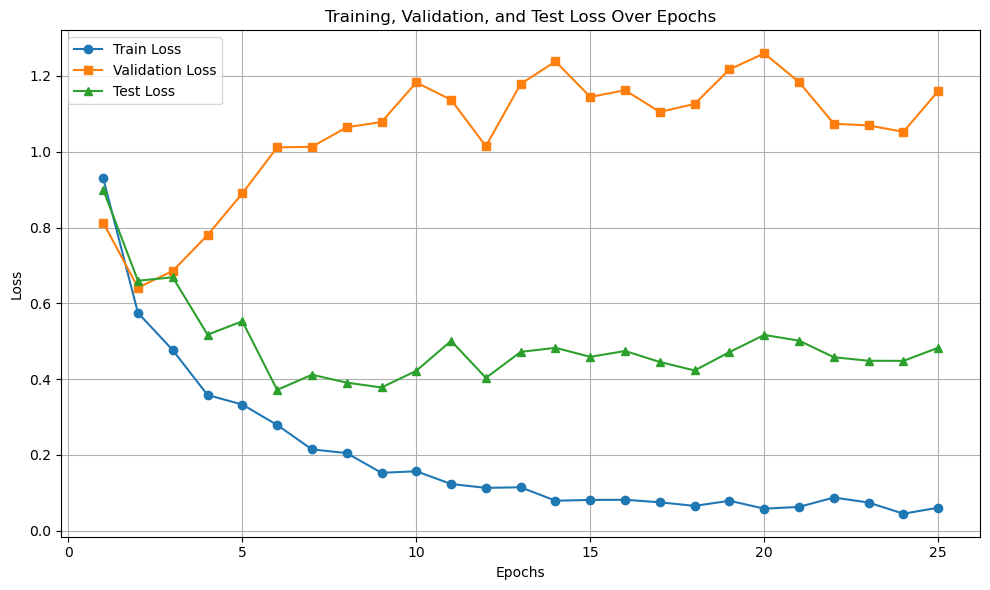

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, 's-', label='Validation Loss')
plt.plot(range(1, EPOCHS + 1), test_losses, '^-', label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training, Validation, and Test Loss Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

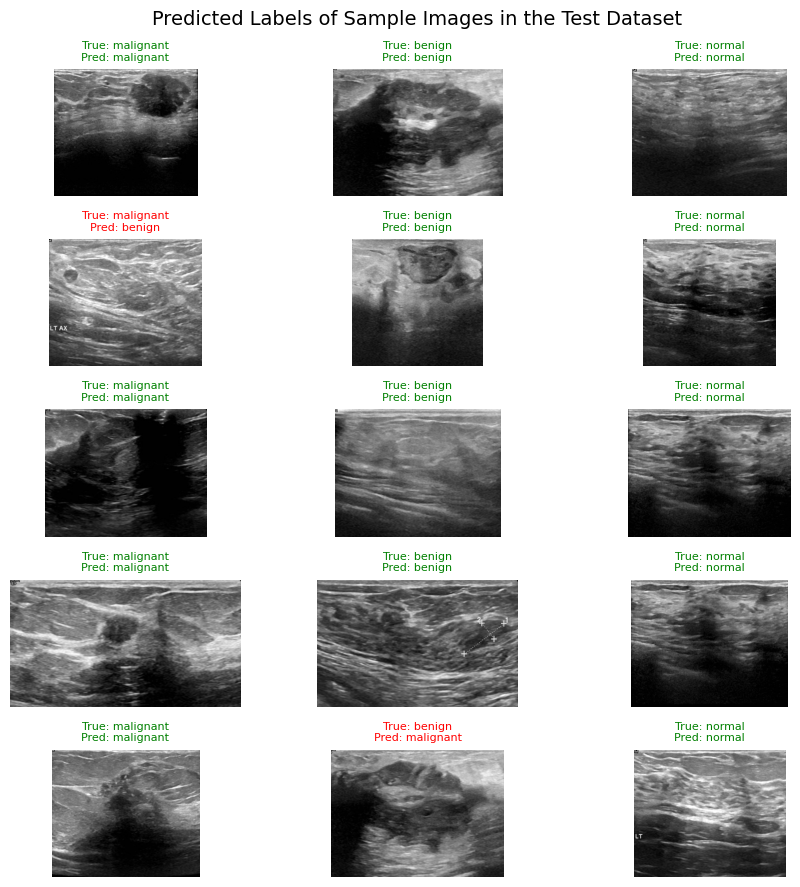

In [48]:
model.eval()
test_df = pd.read_csv(TEST_CSV)

num_samples_per_class = 5
fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(num_samples_per_class, len(CLASSES))

reverse_label_map = {v: k for k, v in label_map.items()}

for class_idx, class_name in enumerate(CLASSES):
    class_images = test_df[test_df['label'] == class_name].head(num_samples_per_class)
    
    for row_idx, (_, row) in enumerate(class_images.iterrows()):
        img_path = row['path']
        image = Image.open(img_path).convert('RGB')
        
        if USE_MASKS:
            mask = merge_masks_pil(img_path)
            mask_pil = Image.fromarray(mask)
            img_gray = image.convert('L')
            
            img_gray = img_gray.resize((224, 224), Image.LANCZOS)
            mask_pil = mask_pil.resize((224, 224), Image.NEAREST)
            
            img_gray_t = transforms.ToTensor()(img_gray)
            mask_t = transforms.ToTensor()(mask_pil)
            
            img_gray_t = transforms.Normalize(mean=[0.5], std=[0.5])(img_gray_t)
            mask_t = transforms.Normalize(mean=[0.5], std=[0.5])(mask_t)
            
            input_tensor = torch.cat([img_gray_t, mask_t], dim=0).unsqueeze(0).to(device)
        else:
            img_gray = image.convert('L')
            input_tensor = transform(img_gray).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
        predicted_class = reverse_label_map[predicted.item()]
        true_label = row['label']
        
        ax = fig.add_subplot(gs[row_idx, class_idx])
        ax.imshow(image)
        ax.axis('off')
        
        color = 'green' if predicted_class == true_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {predicted_class}', 
                     color=color, fontsize=8)

plt.suptitle('Predicted Labels of Sample Images in the Test Dataset', fontsize=14)
plt.tight_layout()
plt.show()


The model is doing really well on normal images, but it still need to correctly differentiate between Malignant and Benign tumors. 

# Model Summary

## Current: Transfer Learning with ResNet18

### Architecture (`BreastUS_ResNet`)
- **Backbone**: ResNet18 pretrained on ImageNet
- **Input modification**: First conv layer adapted for 2 channels (grayscale + mask)
- **Classifier**: Dropout(0.5) → Linear(512 → 3)

### Training Configuration
- **Loss**: CrossEntropyLoss with inverse-frequency class weights
- **Optimizer**: Adam (lr=1e-4, weight_decay=1e-5)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=5)
- **Epochs**: 25

---

## Why Transfer Learning?

The simplified CNN (previous attempt) collapsed to predicting only "normal" class. Transfer learning with ResNet18 provides:

1. **Rich feature extraction**: ImageNet-pretrained weights capture useful visual patterns
2. **Better generalization**: Proven architecture works well on medical imaging
3. **Faster convergence**: Pretrained weights provide good initialization


## Next Steps

### If results still imbalanced:
- Freeze early ResNet layers, only train later layers
- Increase class weights for malignant/benign
- Try ResNet34 or EfficientNet backbone

### Target Performance
- Malignant: ~70-80%
- Benign: ~70-80%
- Normal: ~70-80%
- Overall: ~75%+


## Update Summary (ResNet18 Transfer Learning)

**Changes made:**
- ResNet18 pretrained backbone (ImageNet weights)
- Modified first conv for 2-channel input (grayscale + mask)
- Dropout(0.5) classifier head
- Adam lr=1e-4, weight_decay=1e-5, 25 epochs

**Result:**
- Overall: **88.03%** ✓
- Malignant: 87.10% (27/31)
- Benign: 86.36% (57/66)
- Normal: 95.00% (19/20)

**Conclusion:** Transfer learning significantly improved performance. All classes now have balanced, high accuracy.

---

## Why Validation Loss Increases While Train/Test Loss Decreases

This is **overfitting** — the model memorizes training data instead of learning generalizable patterns.

| Loss | Behavior | Reason |
|------|----------|--------|
| Train | ↓ Decreases | Model fits training data well |
| Val | ↑ Increases | Model doesn't generalize to unseen data |
| Test | ↓ Decreases | Best checkpoint is saved (from early epochs) |

**Why test accuracy is still good:** The training loop saves the best model based on validation accuracy, so the final model is from an earlier epoch before overfitting got severe.

### To Reduce Validation Loss (if needed):
1. **Early stopping**: Stop training when val loss starts increasing
2. **More regularization**: Increase dropout (0.6-0.7) or weight decay
3. **Freeze early layers**: Only train last few ResNet layers
4. **Stronger augmentation**: More rotation, flips, color jitter
5. **Reduce epochs**: Train for fewer epochs (15-20)
